# Toxic Comment Classification with PyTorch and RNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import re
import torch
import torch
import torch.nn as nn


from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [2]:

train_path = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv"

df = pd.read_csv(train_path)
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
    Exploratory data analysis

</div>

In [3]:
df.shape ,df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


((159571, 8), None)

In [4]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [5]:
df["comment_text"].sample(5, random_state=42)

119105    Geez, are you forgetful!  We've already discus...
131631    Carioca RFA \n\nThanks for your support on my ...
125326    "\n\n Birthday \n\nNo worries, It's what I do ...
111256    Pseudoscience category? \n\nI'm assuming that ...
83590     (and if such phrase exists, it would be provid...
Name: comment_text, dtype: object

In [6]:
df.nunique()

id               159571
comment_text     159571
toxic                 2
severe_toxic          2
obscene               2
threat                2
insult                2
identity_hate         2
dtype: int64

In [7]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

for col in label_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


toxic:
toxic
0    144277
1     15294
Name: count, dtype: int64

severe_toxic:
severe_toxic
0    157976
1      1595
Name: count, dtype: int64

obscene:
obscene
0    151122
1      8449
Name: count, dtype: int64

threat:
threat
0    159093
1       478
Name: count, dtype: int64

insult:
insult
0    151694
1      7877
Name: count, dtype: int64

identity_hate:
identity_hate
0    158166
1      1405
Name: count, dtype: int64


In [8]:
df["comment_length"] = df["comment_text"].str.len()

df["comment_length"].describe()

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: comment_length, dtype: float64

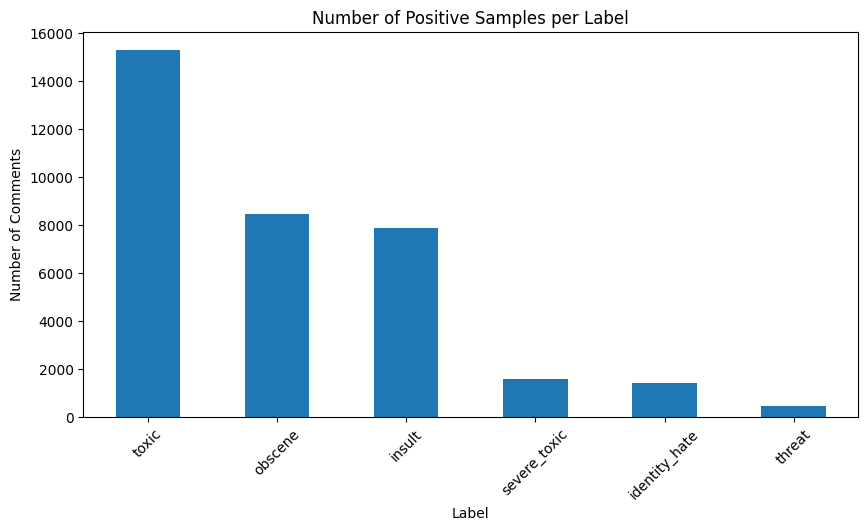

In [9]:

label_counts = df[label_columns].sum().sort_values(ascending=False)

label_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Number of Positive Samples per Label")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

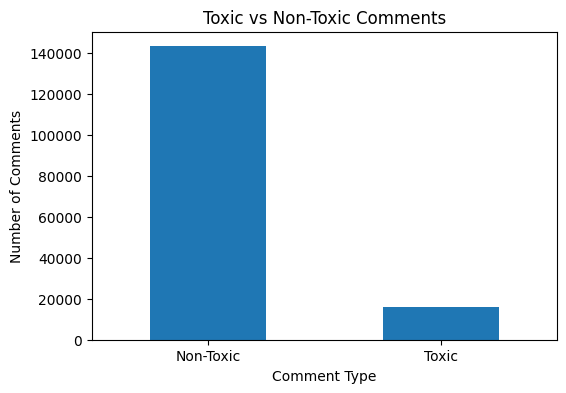

In [10]:

df["any_toxic"] = df[label_columns].sum(axis=1) > 0


df["any_toxic"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Comment Type")
plt.ylabel("Number of Comments")

plt.xticks(
    [0, 1],
    ["Non-Toxic", "Toxic"],
    rotation=0
)

plt.show()

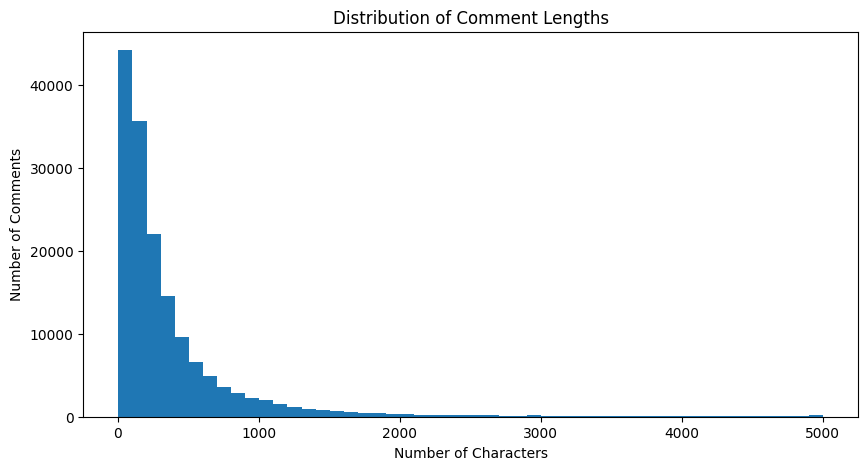

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["comment_length"],
    bins=50
)

plt.title("Distribution of Comment Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")

plt.show()

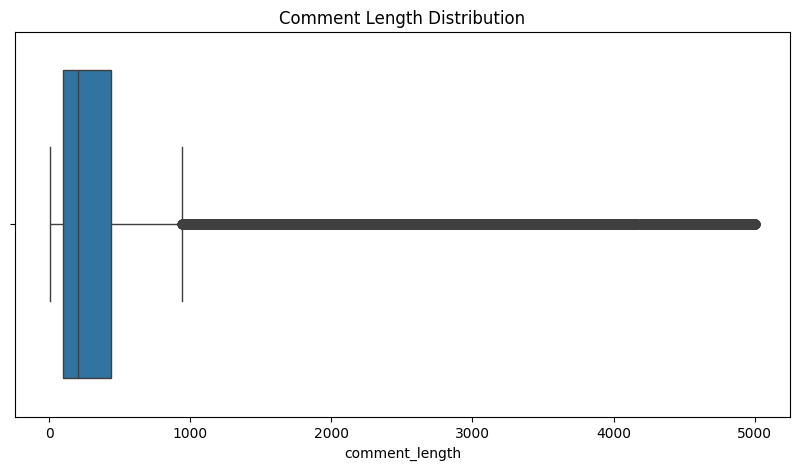

In [12]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["comment_length"]
)

plt.title("Comment Length Distribution")

plt.show()

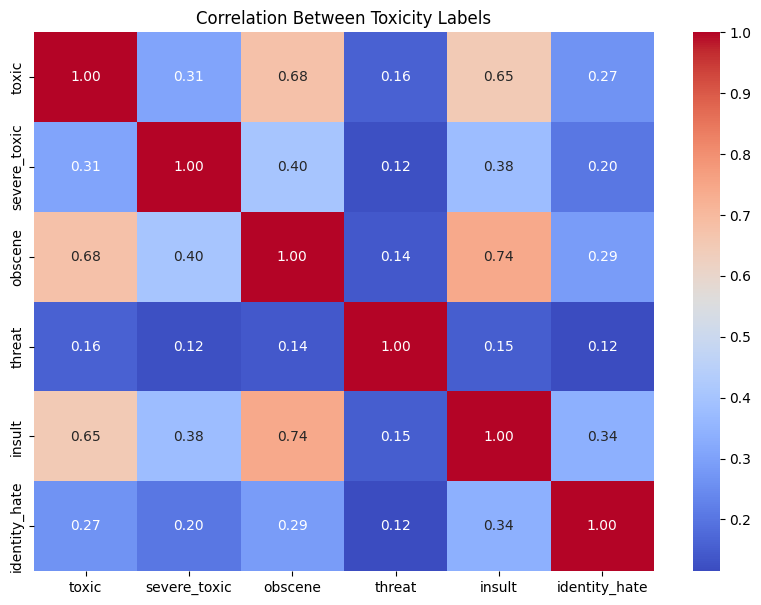

In [13]:
label_corr = df[label_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    label_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Toxicity Labels")

plt.show()

<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
    Data Preprocessing
</div>

In [14]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

X = df["comment_text"].astype(str)
y = df[label_columns].values.astype(np.float32)

In [15]:
def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Keep letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["clean_text"] = df["comment_text"].apply(clean_text)

In [16]:
print("Original:")
print(df["comment_text"].iloc[0])

print("\nCleaned:")
print(df["clean_text"].iloc[0])

Original:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Cleaned:
explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the template from the talk page since i m retired now


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    df["clean_text"],
    df[label_columns],
    test_size=0.2,
    random_state=42
)

In [18]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Training: (127656,)
Validation: (31915,)
y_train: (127656, 6)
y_val: (31915, 6)


In [19]:

def tokenize(text):
    return text.split()




counter = Counter()

for text in X_train:
    counter.update(tokenize(text))


counter.most_common(20)

[('the', 399080),
 ('to', 238867),
 ('i', 193251),
 ('and', 180193),
 ('of', 180106),
 ('you', 174586),
 ('a', 173716),
 ('is', 141374),
 ('that', 128794),
 ('it', 119154),
 ('in', 116924),
 ('for', 82444),
 ('this', 78391),
 ('not', 75181),
 ('on', 72267),
 ('be', 66739),
 ('as', 62226),
 ('s', 59500),
 ('have', 57916),
 ('are', 57656)]

In [20]:
MAX_VOCAB_SIZE = 50000

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, count in counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 50000


In [21]:
def text_to_ids(text):
    tokens = tokenize(text)
    
    return [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]

In [22]:
sample_text = X_train.iloc[0]

print("Text:")
print(sample_text)

print("\nIDs:")
print(text_to_ids(sample_text))

Text:
grandma terri should burn in trash grandma terri is trash i hate grandma terri f k her to hell

IDs:
[12053, 7654, 60, 3731, 12, 4116, 12053, 7654, 9, 4116, 4, 385, 12053, 7654, 468, 877, 185, 3, 816]


In [23]:
train_lengths = [
    len(text_to_ids(text))
    for text in X_train
]

In [24]:
print("Mean:", np.mean(train_lengths))
print("Median:", np.median(train_lengths))
print("95th percentile:", np.percentile(train_lengths, 95))
print("Maximum:", np.max(train_lengths))

Mean: 67.84266309456665
Median: 36.0
95th percentile: 232.0
Maximum: 1403


In [25]:
MAX_LEN = int(np.percentile(train_lengths, 95))

print("MAX_LEN:", MAX_LEN)

MAX_LEN: 232


In [26]:
class ToxicCommentDataset(Dataset):

    def __init__(self, texts, labels, vocab):
        self.texts = texts.tolist()
        self.labels = labels.values.astype(np.float32)
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]
        tokens = tokenize(text)

        token_ids = [
            self.vocab.get(token, self.vocab[UNK_TOKEN])
            for token in tokens
        ]

        x = torch.tensor(token_ids, dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)

        return x, y

In [27]:
train_dataset = ToxicCommentDataset(
    X_train,
    y_train,
    vocab
)

val_dataset = ToxicCommentDataset(
    X_val,
    y_val,
    vocab
)

In [28]:
from torch.nn.utils.rnn import pad_sequence

In [29]:
def collate_fn(batch):

    sequences, labels = zip(*batch)

    sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )

    labels = torch.stack(labels)

    return sequences, labels

In [30]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [31]:
x_batch, y_batch = next(iter(train_loader))

print("X shape:", x_batch.shape)
print("Y shape:", y_batch.shape)

X shape: torch.Size([64, 835])
Y shape: torch.Size([64, 6])


<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
    The Model
</div>

In [32]:

class ToxicRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        num_classes=6
    ):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        # Simple RNN
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully Connected layer
        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )


    def forward(self, x):

        # [batch_size, sequence_length]
        x = self.embedding(x)

        # [batch_size, sequence_length, embedding_dim]
        output, hidden = self.rnn(x)

        # آخر hidden state
        hidden = hidden[-1]

        # [batch_size, 6]
        output = self.fc(hidden)

        return output

In [33]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [34]:
model = ToxicRNN(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=6
)

model = model.to(device)

print(model)

ToxicRNN(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


In [35]:
# Calculate positive weights from training data

pos_weight = []

for i, label in enumerate(label_columns):

    positive = y_train[label].sum()
    negative = len(y_train[label]) - positive

    weight = negative / positive

    pos_weight.append(weight)

    print(
        f"{label}: "
        f"Positive = {int(positive)}, "
        f"Negative = {int(negative)}, "
        f"pos_weight = {weight:.2f}"
    )

pos_weight = torch.tensor(
    pos_weight,
    dtype=torch.float32
).to(device)

print("\npos_weight:", pos_weight)

toxic: Positive = 12238, Negative = 115418, pos_weight = 9.43
severe_toxic: Positive = 1274, Negative = 126382, pos_weight = 99.20
obscene: Positive = 6734, Negative = 120922, pos_weight = 17.96
threat: Positive = 404, Negative = 127252, pos_weight = 314.98
insult: Positive = 6263, Negative = 121393, pos_weight = 19.38
identity_hate: Positive = 1111, Negative = 126545, pos_weight = 113.90

pos_weight: tensor([  9.4311,  99.2009,  17.9569, 314.9802,  19.3826, 113.9019],
       device='cuda:0')


In [37]:
import torch.optim as optim
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [38]:
model.train()

x_batch, y_batch = next(iter(train_loader))

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

outputs = model(x_batch)

print("Input shape :", x_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([64, 351])
Target shape: torch.Size([64, 6])
Output shape: torch.Size([64, 6])


In [39]:
EPOCHS = 20

for epoch in range(EPOCHS):

    # Training
    model.train()
    total_train_loss = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward
        outputs = model(x_batch)

        # Weighted loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)


    # Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)

            loss = criterion(outputs, y_batch)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)


    # Print results
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/20] Train Loss: 1.3520 Val Loss: 1.3533
Epoch [2/20] Train Loss: 1.3504 Val Loss: 1.3322
Epoch [3/20] Train Loss: 1.3511 Val Loss: 1.3169
Epoch [4/20] Train Loss: 1.3456 Val Loss: 1.3133
Epoch [5/20] Train Loss: 1.3433 Val Loss: 1.3277
Epoch [6/20] Train Loss: 1.3419 Val Loss: 1.3172
Epoch [7/20] Train Loss: 1.3337 Val Loss: 1.2999
Epoch [8/20] Train Loss: 1.2716 Val Loss: 1.2890
Epoch [9/20] Train Loss: 1.2923 Val Loss: 1.3100
Epoch [10/20] Train Loss: 1.2497 Val Loss: 1.1582
Epoch [11/20] Train Loss: 1.0731 Val Loss: 1.0809
Epoch [12/20] Train Loss: 1.0799 Val Loss: 1.1173
Epoch [13/20] Train Loss: 1.1479 Val Loss: 1.3705
Epoch [14/20] Train Loss: 1.3498 Val Loss: 1.3301
Epoch [15/20] Train Loss: 1.3410 Val Loss: 1.3513
Epoch [16/20] Train Loss: 1.3396 Val Loss: 1.3424
Epoch [17/20] Train Loss: 1.3406 Val Loss: 1.3381
Epoch [18/20] Train Loss: 1.3402 Val Loss: 1.3378
Epoch [19/20] Train Loss: 1.3400 Val Loss: 1.3464
Epoch [20/20] Train Loss: 1.3387 Val Loss: 1.3408


In [40]:
test_path = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv"
test_labels_path = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test_labels.csv"

test_df = pd.read_csv(test_path)
test_labels_df = pd.read_csv(test_labels_path)

print("Test shape:", test_df.shape)
print("Test labels shape:", test_labels_df.shape)

print(test_df.head())
print(test_labels_df.head())

Test shape: (153164, 2)
Test labels shape: (153164, 7)
                 id                                       comment_text
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...
3  00017563c3f7919a  :If you have a look back at the source, the in...
4  00017695ad8997eb          I don't anonymously edit articles at all.
                 id  toxic  severe_toxic  obscene  threat  insult  \
0  00001cee341fdb12     -1            -1       -1      -1      -1   
1  0000247867823ef7     -1            -1       -1      -1      -1   
2  00013b17ad220c46     -1            -1       -1      -1      -1   
3  00017563c3f7919a     -1            -1       -1      -1      -1   
4  00017695ad8997eb     -1            -1       -1      -1      -1   

   identity_hate  
0             -1  
1             -1  
2             -1  
3             -1  
4        

In [41]:
# Clean test comments
test_df["clean_text"] = test_df["comment_text"].astype(str).apply(clean_text)

print(test_df[["comment_text", "clean_text"]].head())

                                        comment_text  \
0  Yo bitch Ja Rule is more succesful then you'll...   
1  == From RfC == \n\n The title is fine as it is...   
2  " \n\n == Sources == \n\n * Zawe Ashton on Lap...   
3  :If you have a look back at the source, the in...   
4          I don't anonymously edit articles at all.   

                                          clean_text  
0  yo bitch ja rule is more succesful then you ll...  
1            from rfc the title is fine as it is imo  
2                     sources zawe ashton on lapland  
3  if you have a look back at the source the info...  
4           i don t anonymously edit articles at all  


In [42]:
class TestToxicCommentDataset(Dataset):

    def __init__(self, texts, vocab):
        self.texts = texts.tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]

        tokens = tokenize(text)

        token_ids = [
            self.vocab.get(token, self.vocab[UNK_TOKEN])
            for token in tokens
        ]

        x = torch.tensor(token_ids, dtype=torch.long)

        return x

In [43]:
test_dataset = TestToxicCommentDataset(
    test_df["clean_text"],
    vocab
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=lambda batch: pad_sequence(
        batch,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )
)

print("Test dataset size:", len(test_dataset))

Test dataset size: 153164


In [44]:
model.eval()

test_predictions = []

with torch.no_grad():

    for x_batch in test_loader:

        x_batch = x_batch.to(device)

        outputs = model(x_batch)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        test_predictions.append(
            probabilities.cpu().numpy()
        )

# Combine all batches
test_predictions = np.vstack(test_predictions)

print("Test predictions shape:", test_predictions.shape)

Test predictions shape: (153164, 6)


In [46]:
test_true_labels = test_labels_df[label_columns].values

print("Test true labels shape:", test_true_labels.shape)

Test true labels shape: (153164, 6)


In [48]:
test_predictions_binary = (
    test_predictions >= 0.5
).astype(int)

print("Binary predictions shape:", test_predictions_binary.shape)

Binary predictions shape: (153164, 6)



Classification Report - toxic
              precision    recall  f1-score   support

   Non-toxic       0.90      0.51      0.65     57888
       toxic       0.10      0.49      0.16      6090

    accuracy                           0.51     63978
   macro avg       0.50      0.50      0.40     63978
weighted avg       0.83      0.51      0.60     63978


Classification Report - severe_toxic
                  precision    recall  f1-score   support

Non-severe_toxic       0.99      0.51      0.67     63611
    severe_toxic       0.01      0.51      0.01       367

        accuracy                           0.51     63978
       macro avg       0.50      0.51      0.34     63978
    weighted avg       0.99      0.51      0.67     63978


Classification Report - obscene
              precision    recall  f1-score   support

 Non-obscene       0.94      0.51      0.66     60287
     obscene       0.06      0.49      0.10      3691

    accuracy                           0.51     63978
  

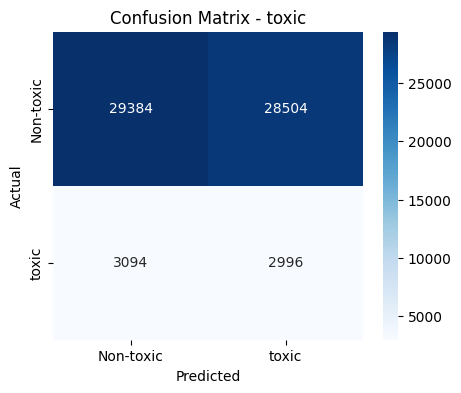

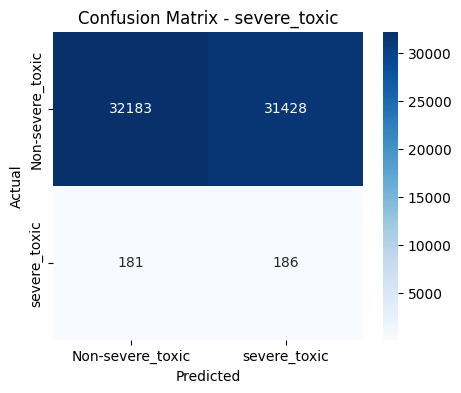

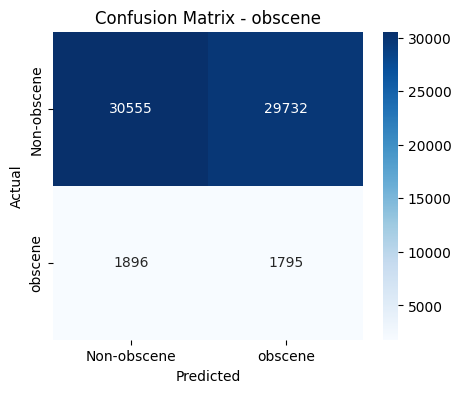

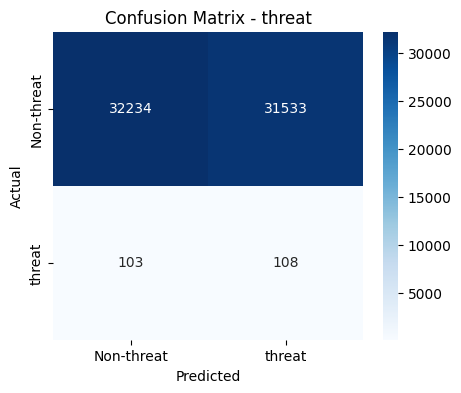

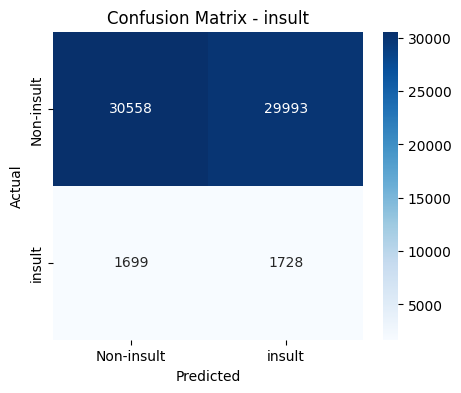

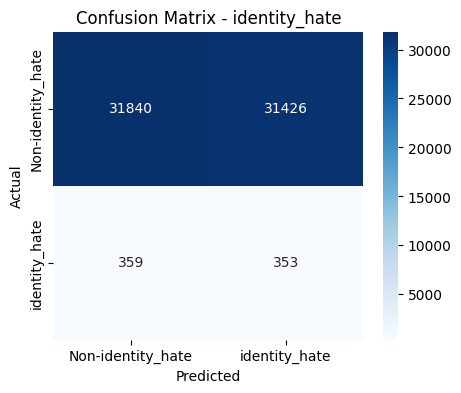

In [49]:

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Classification Report

for i, label in enumerate(label_columns):

    # Ignore -1 labels
    mask = test_true_labels[:, i] != -1

    y_true = test_true_labels[mask, i]
    y_pred = test_predictions_binary[mask, i]

    print("\n" + "=" * 60)
    print(f"Classification Report - {label}")
    print("=" * 60)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["Non-" + label, label],
            zero_division=0
        )
    )


# Confusion Matrix

for i, label in enumerate(label_columns):

    # Ignore -1 labels
    mask = test_true_labels[:, i] != -1

    y_true = test_true_labels[mask, i]
    y_pred = test_predictions_binary[mask, i]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-" + label, label],
        yticklabels=["Non-" + label, label]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {label}")

    plt.show()